# running renewable energy simulations using RESKit

### We already have the placements of wind turbines and solar panels in hand.
### You will learn how to simulation wind energy or solar energy on the top of these placements.

## Import required packages

In [14]:
import geokit as gk
import reskit as rk
import os
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Define input and output paths and filenames

In [2]:
# NOTE: The results folder exists in your repo under /student_files/results/, but the files created therein will not be pushed back to git

# this is the current working directory ("student_files/exercises")
cwd = pathlib.Path().cwd()
print(f"Current working directory: {cwd}")

# the results folder is in "student_files/results", so go "2 folders up"
results_folder = os.path.join(os.path.dirname(os.path.dirname(cwd)), 'results')
# make sure folder exists
assert os.path.isdir(results_folder), f"results folder does not exist: '{results_folder}'"

print(f"Results folder:", results_folder)

Current working directory: /storage_cluster/projects/2021_s-chen_PhD/projects_root/0013_IMP_master_students_teach_repo/imp_egh_ice-2_v2024-25/student_files/exercises/Unit_05_RenewableEnergySimulationsRESKit
Results folder: /storage_cluster/projects/2021_s-chen_PhD/projects_root/0013_IMP_master_students_teach_repo/imp_egh_ice-2_v2024-25/student_files/results


In [3]:
# we determine our datafolder, here in a one line
data_basefolder = os.path.join(os.path.dirname(os.path.dirname(cwd)), 'data')
print(data_basefolder)

/storage_cluster/projects/2021_s-chen_PhD/projects_root/0013_IMP_master_students_teach_repo/imp_egh_ice-2_v2024-25/student_files/data


## wind workflow

In [4]:
# define necessary files
era5_path = os.path.join(data_basefolder, 'weather_data/ERA5')
gwa_100m = os.path.join(data_basefolder, 'weather_data/global_wind_atlas/gwa3_250_wind-speed_100m_NER5.1.tif')
esa_cci = os.path.join(data_basefolder, 'weather_data/global_land_surface_cover/C3S-LC-L4-LCCS-Map-300m-P1Y-2018-v2.1.1_NER5.1.tif')


In [5]:
# read wind placements
results_folder2 = "/storage_cluster/projects/2021_s-chen_PhD/projects_root/0013_IMP_master_students_teach_repo/solar_wind_placements/"
wind_placements = gk.vector.extractFeatures(os.path.join(results_folder2, 'placements_wind_1000m_separation.shp'))
# define the wind turbines parameters for these placements
wind_placements["hub_height"] = np.linspace(100, 130, wind_placements.shape[0])
wind_placements["capacity"] = 3000
wind_placements["rotor_diam"] = 170
wind_placements.loc[::2, "rotor_diam"] = 150


### call RESKit to simulate wind power

In [6]:
gen = rk.wind.wind_era5_PenaSanchezDunkelWinklerEtAl2025(
        placements=wind_placements,
        era5_path=era5_path,
        gwa_100m_path=gwa_100m,
        esa_cci_path=esa_cci,
        output_netcdf_path=None,
        cf_correction=True,
    )
gen

2025-03-24 15:36:42.975443 Now extracting correction factors for a total of 58 placements from /fast/home/s-chen/local_bin/python_envs_managed_by_mamba/reskit_workingV3/RESKit/reskit/wind/core/data/cf_correction_factors_PSDW2025.tif:
2025-03-24 15:36:42.977834 Based on max_batch_size=58, the total of 58 placements were split into 1 sub batches. Proceeding with batch 1/1 (id=0) with 58 placements.
2025-03-24 15:36:43.001544 Maximum rel. deviation after initial simulation is 0.0787, Number/share of placements with deviation > tolerance (0.01): 58/58. More iterations required.
2025-03-24 15:36:43.025473 Maximum rel. deviation after 1 additional iteration(s) is 0.0134, Number/share of placements with deviation > tolerance (0.01): 6/58. More iterations required.
2025-03-24 15:36:43.037101 Required tolerance of 0.01 reached after 2 additional iteration(s). Maximum remaining rel. deviation: 0.0098.


<xarray.Dataset> Size: 20MB
Dimensions:                         (location: 58, time: 8760)
Coordinates:
  * location                        (location) int64 464B 0 1 2 3 ... 55 56 57
  * time                            (time) datetime64[ns] 70kB 2017-12-31T23:...
Data variables: (12/14)
    FID                             (location) int64 464B 0 1 2 3 ... 55 56 57
    hub_height                      (location) float64 464B 100.0 ... 130.0
    capacity                        (location) int64 464B 3000 3000 ... 3000
    rotor_diam                      (location) int64 464B 150 170 ... 150 170
    lon                             (location) float64 464B 2.214 ... 2.134
    lat                             (location) float64 464B 13.63 ... 13.45
    ...                              ...
    roughness                       (location) float64 464B 0.03 ... 0.0002
    elevated_wind_speed             (time, location) float64 4MB 8.327 ... 6.594
    surface_pressure                (time, location) float64 4MB 9.886e+04 .....
    surface_air_temperature         (time, location) float64 4MB 20.62 ... 21.62
    boundary_layer_height           (time, location) float64 4MB 266.0 ... 180.7
    capacity_factor                 (time, location) float64 4MB 0.9036 ... 0...

In [24]:
# contained varaibles
gen.data_vars

Data variables:
    FID                             (location) int64 464B 0 1 2 3 ... 55 56 57
    hub_height                      (location) float64 464B 100.0 ... 130.0
    capacity                        (location) int64 464B 3000 3000 ... 3000
    rotor_diam                      (location) int64 464B 150 170 ... 150 170
    lon                             (location) float64 464B 2.214 ... 2.134
    lat                             (location) float64 464B 13.63 ... 13.45
    powerCurve                      (location) object 464B 'SPC:170,25' ... '...
    LRA_factor_elevated_wind_speed  (location) float64 464B 1.112 ... 0.9822
    roughness                       (location) float64 464B 0.03 ... 0.0002
    elevated_wind_speed             (time, location) float64 4MB 8.327 ... 6.594
    surface_pressure                (time, location) float64 4MB 9.886e+04 .....
    surface_air_temperature         (time, location) float64 4MB 20.62 ... 21.62
    boundary_layer_height           (time, lo

### 58 wind turbines 
### simulated in 2018, hourly, 24*365=8760

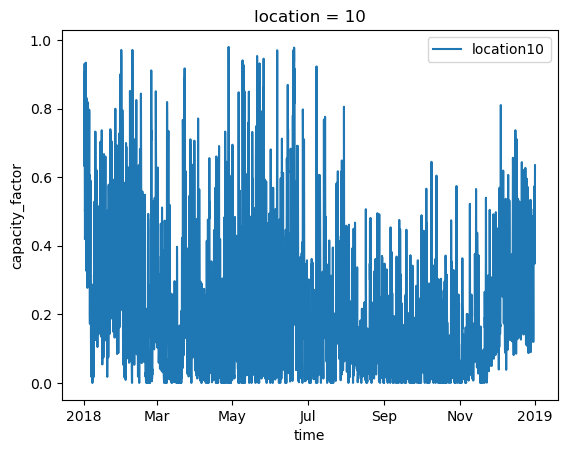

In [27]:
# explore time series for variables: 
# 'capacity_factor', 'boundary_layer_height', 'elevated_wind_speed', 'roughness', 'surface_air_temperature', 'surface_pressure'
# select some random wind placements
gen['capacity_factor'].isel(location=10).plot(label='location10')
# gen['boundary_layer_height'].isel(location=50).plot(label='location15')
# plt.xlim(pd.Timestamp("2018-03-03"), pd.Timestamp("2018-03-08"))
plt.legend()
plt.show()

In [ ]:
# yearly mean capacity factor
mean_cf = gen['capacity_factor'].mean(axis=0)
mean_cf

<xarray.DataArray 'capacity_factor' (location: 58)> Size: 464B
array([0.24895927, 0.32689175, 0.25775018, 0.29645179, 0.25302929,
       0.32441188, 0.22033275, 0.34776833, 0.21741501, 0.31408016,
       0.20919364, 0.27088699, 0.26401804, 0.28634123, 0.24102955,
       0.25929122, 0.20359411, 0.32323018, 0.26204003, 0.30891424,
       0.24761591, 0.25055982, 0.19265793, 0.24626091, 0.21706027,
       0.30448645, 0.20827707, 0.27726795, 0.18704486, 0.2421712 ,
       0.23202686, 0.23417637, 0.25270396, 0.28048685, 0.24952814,
       0.22867148, 0.26011091, 0.31326863, 0.25215378, 0.22676182,
       0.23660992, 0.33818312, 0.24478342, 0.33202165, 0.18242789,
       0.30374474, 0.22984166, 0.32413534, 0.2366097 , 0.28735603,
       0.21495729, 0.32450642, 0.24979327, 0.32110092, 0.23869992,
       0.21260205, 0.2546078 , 0.22279562])
Coordinates:
  * location  (location) int64 464B 0 1 2 3 4 5 6 7 ... 50 51 52 53 54 55 56 57

In [51]:
# perform an analysis here, for example, calculate the mean capacity factor for each wind turbine placement
# and add it to the wind_placements dataframe
wind_placements["mean_cf"] = mean_cf


In [ ]:
# there are many (more elegent) ways to plot the results, here we use a scatter plot to avoid installing additional packages

# get longitude and latitude of the placements
# Ensure geom column is a string
wind_placements["geom"] = wind_placements["geom"].astype(str)
# Remove "POINT (" and ")"
wind_placements["geom_clean"] = wind_placements["geom"].str.replace(r"POINT \(", "", regex=True).str.replace(r"\)", "", regex=True)
# Split into longitude and latitude
wind_placements[["longitude", "latitude"]] = wind_placements["geom_clean"].str.split(" ", expand=True)
# Convert to float
wind_placements["longitude"] = wind_placements["longitude"].astype(float)
wind_placements["latitude"] = wind_placements["latitude"].astype(float)
# Drop intermediate column (optional)
wind_placements = wind_placements.drop(columns=["geom_clean"])

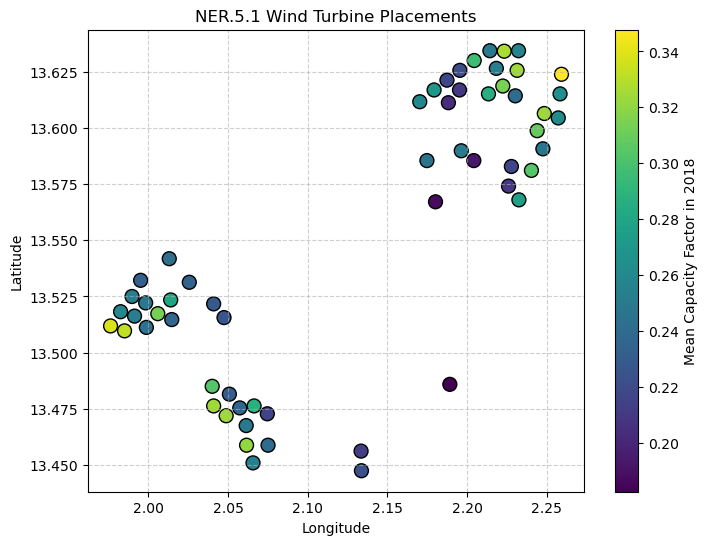

In [54]:
# plot mean capacity factor of all placements
# Plot
# Create figure
plt.figure(figsize=(8, 6))

# Scatter plot
sc = plt.scatter(wind_placements['longitude'], wind_placements['latitude'], c=wind_placements['mean_cf'], cmap="viridis", s=100, edgecolors="black")

# Add color bar
plt.colorbar(sc, label="Mean Capacity Factor in 2018")

# Labels and title
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("NER.5.1 Wind Turbine Placements")

# Grid and show
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()

In [55]:
# save this result to a file
wind_placements.to_csv(os.path.join(results_folder, 'wind_placements_capacity_factor.csv'), index=False)